In [1]:
from langgraph.graph import MessagesState
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
model = ChatOllama(model = 'qwen3:0.6b', temperature=0)
response = model.invoke('what is 2+2?')
print(response.content)

The sum of 2 and 2 is 4.


In [3]:
class ChatState(MessagesState):
    summary: str

In [5]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [8]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [9]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [10]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [11]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

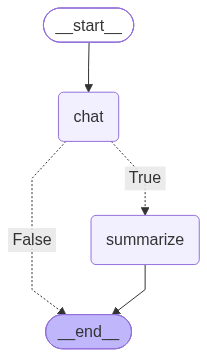

In [12]:
graph

In [13]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [14]:
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [15]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='3be16625-19d6-4cd1-821a-91faf0c1abdc')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics is a fundamental branch of theoretical physics that explores the


In [16]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='3be16625-19d6-4cd1-821a-91faf0c1abdc'), AIMessage(content="Quantum physics is a fundamental branch of theoretical physics that explores the behavior of particles at the smallest scales, governed by quantum mechanics. It deals with phenomena such as wave-particle duality, superposition, entanglement, and quantum field theory. Here's a structured overview:\n\n### **Key Concepts and Areas**\n1. **Quantum Mechanics**  \n   - **Wave-Particle Duality**: Particles can exhibit both wave-like and particle-like properties.  \n   - **Superposition**: Quantum systems can exist in multiple states simultaneously.  \n   - **Entanglement**: Quantum particles can be correlated in such a way that their states are dependent on each other, even if separated by distance.  \n\n2. **Quantum Field Theory (QFT)**  \n   - Explores the behavior of quantum fields (e.g., photons, fermions) and their interactions.  \n   - Inclu

In [17]:
run_turn('What are some of Einstien"s famous work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='3be16625-19d6-4cd1-821a-91faf0c1abdc'), AIMessage(content="Quantum physics is a fundamental branch of theoretical physics that explores the behavior of particles at the smallest scales, governed by quantum mechanics. It deals with phenomena such as wave-particle duality, superposition, entanglement, and quantum field theory. Here's a structured overview:\n\n### **Key Concepts and Areas**\n1. **Quantum Mechanics**  \n   - **Wave-Particle Duality**: Particles can exhibit both wave-like and particle-like properties.  \n   - **Superposition**: Quantum systems can exist in multiple states simultaneously.  \n   - **Entanglement**: Quantum particles can be correlated in such a way that their states are dependent on each other, even if separated by distance.  \n\n2. **Quantum Field Theory (QFT)**  \n   - Explores the behavior of quantum fields (e.g., photons, fermions) and their interactions.  \n   - Inclu

In [18]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='3be16625-19d6-4cd1-821a-91faf0c1abdc'), AIMessage(content="Quantum physics is a fundamental branch of theoretical physics that explores the behavior of particles at the smallest scales, governed by quantum mechanics. It deals with phenomena such as wave-particle duality, superposition, entanglement, and quantum field theory. Here's a structured overview:\n\n### **Key Concepts and Areas**\n1. **Quantum Mechanics**  \n   - **Wave-Particle Duality**: Particles can exhibit both wave-like and particle-like properties.  \n   - **Superposition**: Quantum systems can exist in multiple states simultaneously.  \n   - **Entanglement**: Quantum particles can be correlated in such a way that their states are dependent on each other, even if separated by distance.  \n\n2. **Quantum Field Theory (QFT)**  \n   - Explores the behavior of quantum fields (e.g., photons, fermions) and their interactions.  \n   - Inclu